# Importación de librerías y definición de DataFrames

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
df_tbasics = pd.read_csv('datos\\title.basics.tsv.gz', sep='\t', compression='gzip', na_values='\\N', encoding='utf-8',
                         dtype={'runtimeMinutes': 'str'})

In [115]:
df_tratings = pd.read_csv('datos\\title.ratings.tsv.gz', sep='\t', compression='gzip', na_values='\\N', encoding='utf-8')

# Análisis Exploratorio de Datos

Hacemos un análisis de cada dataset por separado, para luego unirlos en un único dataset.

En el dataset de title.basics tenemos 9 columnas y aproximadamente 10 millones de registros. De las cuales, 3 son numéricas y 6 son categóricas.

In [116]:
df_tbasics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9963680 entries, 0 to 9963679
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   tconst          object 
 1   titleType       object 
 2   primaryTitle    object 
 3   originalTitle   object 
 4   isAdult         float64
 5   startYear       float64
 6   endYear         float64
 7   runtimeMinutes  object 
 8   genres          object 
dtypes: float64(3), object(6)
memory usage: 684.2+ MB


In [117]:
# Convertir la columna 'runtimeMinutes' a tipo numérico
df_tbasics['runtimeMinutes'] = pd.to_numeric(df_tbasics['runtimeMinutes'], errors='coerce')

# Convertir la columna 'isAdult' a tipo booleano
df_tbasics['isAdult'] = df_tbasics['isAdult'].astype('bool')

In [118]:
df_tbasics.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,False,1894.0,NaN,1.0,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,False,1892.0,NaN,5.0,"Animation,Short"
2,tt0000003,short,Pauvre Pierrot,Pauvre Pierrot,False,1892.0,NaN,4.0,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,False,1892.0,NaN,12.0,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,False,1893.0,NaN,1.0,"Comedy,Short"


En el dataset de title.ratings tenemos 3 columnas y 1.3 millones de registros. De las cuales, 2 columnas son numéricas y 1 es categórica.

In [119]:
df_tratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1323907 entries, 0 to 1323906
Data columns (total 3 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   tconst         1323907 non-null  object 
 1   averageRating  1323907 non-null  float64
 2   numVotes       1323907 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 30.3+ MB


In [120]:
df_tratings.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,1982
1,tt0000002,5.8,265
2,tt0000003,6.5,1838
3,tt0000004,5.5,178
4,tt0000005,6.2,2625


Merge de los datasets

In [121]:
df = pd.merge(df_tbasics, df_tratings, on='tconst', how='left')

Al hacer un left join entre los datasets, nos quedamos con los registros que tienen información en title.basics a los que se les agrega la información de title.ratings. De otra manera se perderían registros útiles para el análisis.

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9963680 entries, 0 to 9963679
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   tconst          object 
 1   titleType       object 
 2   primaryTitle    object 
 3   originalTitle   object 
 4   isAdult         bool   
 5   startYear       float64
 6   endYear         float64
 7   runtimeMinutes  float64
 8   genres          object 
 9   averageRating   float64
 10  numVotes        float64
dtypes: bool(1), float64(5), object(5)
memory usage: 769.7+ MB


In [123]:
df.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000001,short,Carmencita,Carmencita,False,1894.0,NaN,1.0,"Documentary,Short",5.7,1982.0
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,False,1892.0,NaN,5.0,"Animation,Short",5.8,265.0
2,tt0000003,short,Pauvre Pierrot,Pauvre Pierrot,False,1892.0,NaN,4.0,"Animation,Comedy,Romance",6.5,1838.0
3,tt0000004,short,Un bon bock,Un bon bock,False,1892.0,NaN,12.0,"Animation,Short",5.5,178.0
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,False,1893.0,NaN,1.0,"Comedy,Short",6.2,2625.0


Hacemos un describe de las columnas numéricas para ver datos estadísticos de cada una.

In [124]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
startYear,8620813.0,2005.186390,20.153625,1874.0,2001.0,2012.0,2018.0,2031.0
endYear,109157.0,2006.050020,16.451545,1906.0,1999.0,2012.0,2018.0,2030.0
runtimeMinutes,2951883.0,43.444595,81.693792,0.0,18.0,30.0,60.0,59460.0
averageRating,1323906.0,6.954503,1.382733,1.0,6.2,7.1,7.9,10.0
numVotes,1323906.0,1038.585748,17467.150183,5.0,11.0,26.0,101.0,2756543.0


Analizamos la cantidad de registros nulos que tiene cada columna.

In [125]:
df.isnull().sum()

tconst                  0
titleType               0
primaryTitle           17
originalTitle          17
isAdult                 0
startYear         1342867
endYear           9854523
runtimeMinutes    7011797
genres             447129
averageRating     8639774
numVotes          8639774
dtype: int64

Analizamos la distribución de los datos de las columnas numéricas startYear y averageRating.

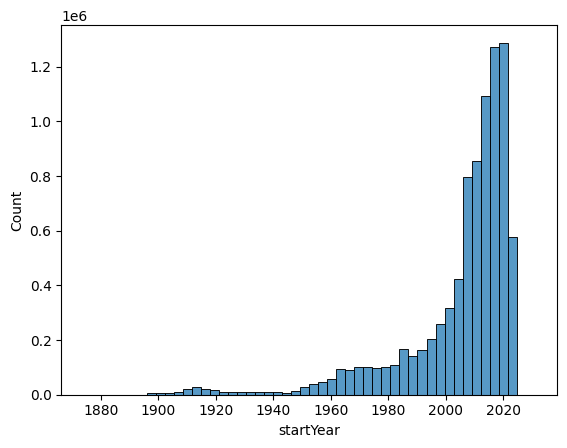

In [126]:
sns.histplot(data=df, x='startYear', bins=50)
plt.show()

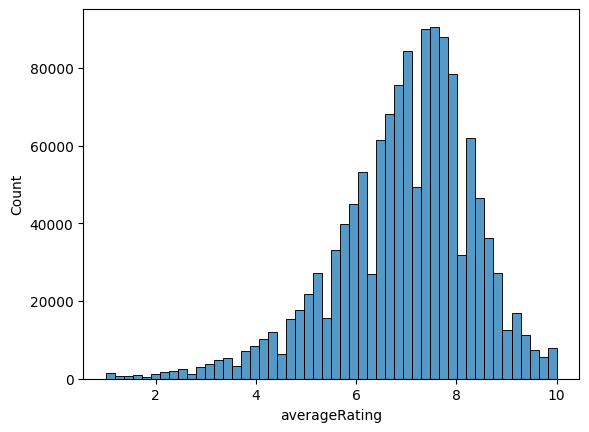

In [127]:
sns.histplot(data=df, x='averageRating', bins=50)
plt.show()

Analizamos la frecuencia de los diferentes tipos de títulos.

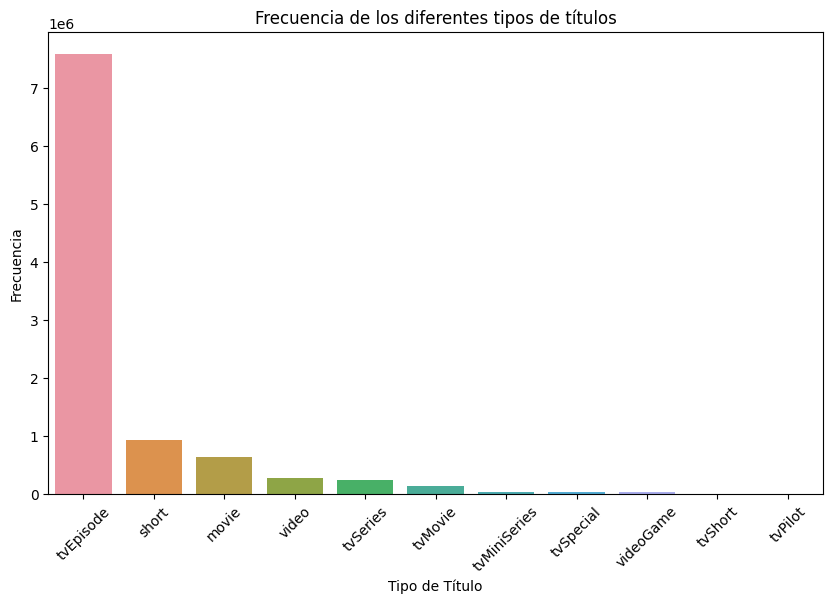

In [128]:
title_type_counts = df['titleType'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=title_type_counts.index, y=title_type_counts.values)
plt.xlabel('Tipo de Título')
plt.ylabel('Frecuencia')
plt.title('Frecuencia de los diferentes tipos de títulos')
plt.xticks(rotation=45)
plt.show()

In [129]:
print('Cantidad de títulos por tipo:')
print(title_type_counts)

Cantidad de títulos por tipo:
titleType
tvEpisode       7576582
short            937864
movie            649312
video            275838
tvSeries         245691
tvMovie          142188
tvMiniSeries      49091
tvSpecial         42148
videoGame         34994
tvShort            9971
tvPilot               1
Name: count, dtype: int64


Es claro que la mayoría de los títulos son de tipo tvEpisode ya que son los episodios de las series. Luego le siguen los short, movie y video.

# Pregunta en base a los datos

¿Cómo ha evolucionado el número de mini series (tvMiniSeries) en los últimos años y cuál fue el género más común en estas mini series?

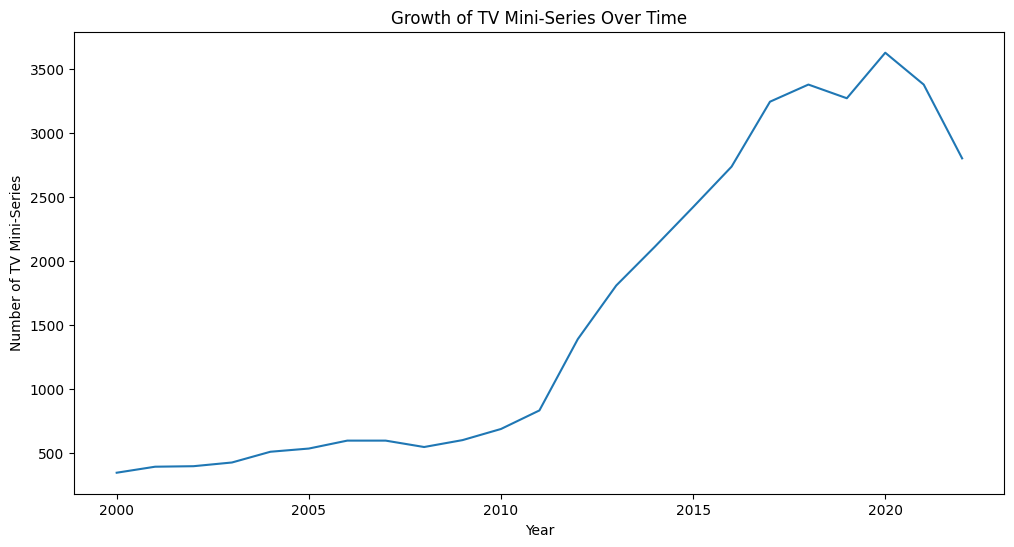

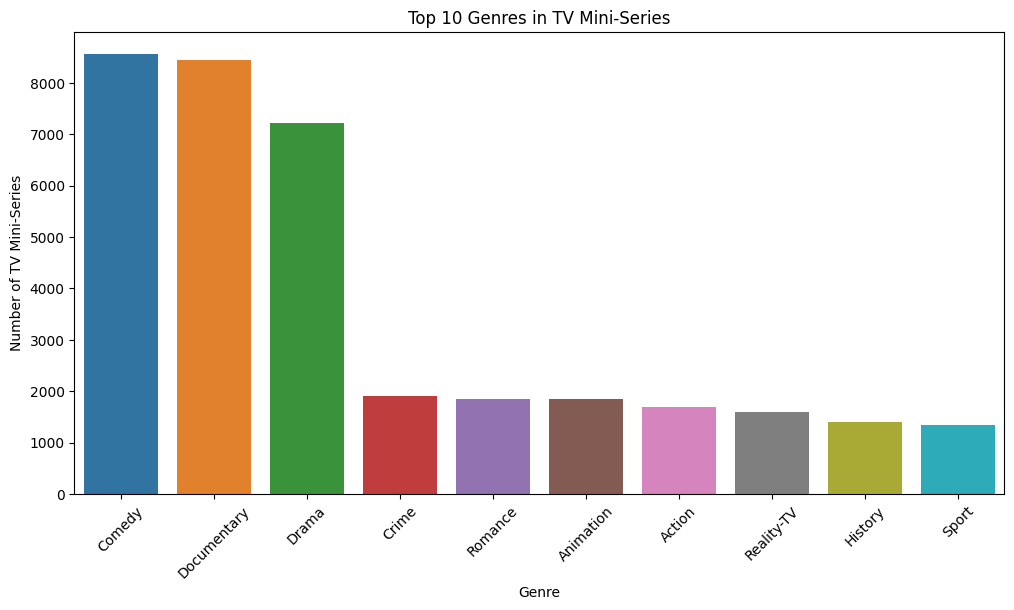

In [130]:
# Filtrar los registros con títuloType 'tvMiniSeries'
df_miniseries = df[df['titleType'] == 'tvMiniSeries']

# Filtrar los registros de mini series desde el año 2000
df_miniseries = df[(df['titleType'] == 'tvMiniSeries') & (df['startYear'] >= 2000) & (df['startYear'] < 2023)]

# Contar la cantidad de mini series por año de inicio
miniseries_counts = df_miniseries['startYear'].value_counts().sort_index()

# Obtener los géneros más comunes en las miniseries
top_genres = df_miniseries['genres'].str.split(',', expand=True).stack().value_counts().head(10)

# Gráfico de crecimiento del surgimiento de miniseries en el tiempo
plt.figure(figsize=(12, 6))
sns.lineplot(data=miniseries_counts)
plt.xlabel('Year')
plt.ylabel('Number of TV Mini-Series')
plt.title('Growth of TV Mini-Series Over Time')
plt.show()

# Gráfico de barras de los géneros más comunes en las miniseries
plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.index, y=top_genres.values)
plt.xlabel('Genre')
plt.ylabel('Number of TV Mini-Series')
plt.title('Top 10 Genres in TV Mini-Series')
plt.xticks(rotation=45)
plt.show()

En los últimos años ha habido un aumento en el número de miniseries, alcanzando su punto máximo en 2020. Los géneros más comunes en las miniseries son Comedy, Documentary y Drama.

# Modelo que se pueda utilizar

Teniendo en cuenta los datos y la información proporcionada en la documentación, se podría usar un modelo de recomendación para sugerir títulos a usuarios en función de las características y atributos de los elementos. Esto se basa en variables como el género del título, el año de inicio, la calificación promedio, entre otras, para identificar patrones y similitudes entre los títulos. Con esta información, el modelo puede hacer recomendaciones personalizadas a los usuarios, sugiriendo títulos que sean relevantes para ellos. Esto podría aplicarse en plataformas de streaming de contenido para mejorar la experiencia del usuario y ayudarles a descubrir nuevos títulos.

Para hacer el modelo de recomendación, hay varios enfoques y algoritmos de machine learning que se pueden utilizar, como por ejemplo Content-Based Filtering, que se basa en las características y atributos de los elementos (en este caso, los títulos) para hacer recomendaciones. En lugar de analizar las preferencias de los usuarios, este enfoque busca encontrar similitudes entre los elementos en función de sus características.